In [5]:
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib import patheffects
import matplotlib.pyplot as plt
from helper_utils import save_png_images

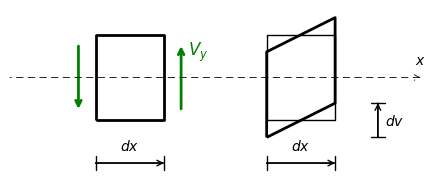

Saved light mode image to: ../_static/sign_convention_beam_Vy_light.png
Saved dark mode image to: ../_static/sign_convention_beam_Vy_dark.png


In [6]:
fig, ax = plt.subplots(figsize=(7.12, 2))

section_height = 1.0
length=0.8

# Draw the beam segment as a thick line
ax.plot(
    [
        0, 
        length, 
        length, 
        0, 
        0
    ], 
    [
        -section_height/2, 
        -section_height/2, 
        section_height/2, 
        section_height/2, 
        -section_height/2
    ], 
    color='black', 
    linewidth=2, 
    solid_capstyle='butt'
)

# Vy shear force
vy_arrow_offset_x = 0.2
vy_text_offset_x = 0.4
vy_text_offset_y = 0.3
# on the right side of the beam segment
ax.annotate(
    "",
    xy=(length + vy_arrow_offset_x, section_height * 0.4),
    xytext=(length + vy_arrow_offset_x, -section_height * 0.4),
    arrowprops=dict(arrowstyle='->', color='g', linewidth=2),
    fontsize=10
)
ax.text(
    length + vy_text_offset_x,
    vy_text_offset_y,
    r"$V_y$",
    ha="center",
    va="center",
    color="g",
    fontsize=12
)
# on the left side of the beam segment
ax.annotate(
    "",
    xy=(-vy_arrow_offset_x, section_height * 0.4),
    xytext=(-vy_arrow_offset_x, -section_height * 0.4),
    arrowprops=dict(arrowstyle='<-', color='g', linewidth=2),
    fontsize=10
)

# Draw the beam as a thick line
second_figure_offset = 2.0
ax.plot(
    [
        second_figure_offset, 
        second_figure_offset + length, 
        second_figure_offset + length, 
        second_figure_offset, 
        second_figure_offset
    ],
    [
        -section_height/2,
        -section_height/2, 
        section_height/2, 
        section_height/2, 
        -section_height/2
    ], 
    color='black', 
    linewidth=1, 
    solid_capstyle='butt'
)
deformation_offset_y = 0.2
ax.plot(
    # x coordinates
    [
        second_figure_offset, 
        second_figure_offset + length, 
        second_figure_offset + length, 
        second_figure_offset, 
        second_figure_offset
    ],
    # y coordinates 
    [
        -section_height/2 - deformation_offset_y, 
        -section_height/2 + deformation_offset_y, 
        section_height/2 + deformation_offset_y, 
        section_height/2 - deformation_offset_y, 
        -section_height/2 - deformation_offset_y
    ], 
    color='black', 
    linewidth=2, 
    solid_capstyle='butt',
)

# horizontal dimension lines
dimension_line_y = -section_height/2 - 0.5
dimension_segments = [
    (0, length, "$dx$"),
    (second_figure_offset, second_figure_offset+length, "$dx$")
]
arrows = '<-', '|-|'
for segment in dimension_segments:
    for arr in arrows:
        arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
        if arr == '|-|':
            arrowprops["mutation_scale"] = 5
        ax.annotate(
            "", 
            xy=(segment[0], dimension_line_y), 
            xytext=(segment[1], dimension_line_y), 
            arrowprops=arrowprops
        )
    bbox=dict(fc="white", ec="none")
    ax.text((segment[0] + segment[1]) / 2, dimension_line_y + 0.2, segment[2], color="black", \
        ha="center", va="center", bbox=bbox, fontsize=10)
    
# dv
dv_offset_x = 0.5
dv_x = second_figure_offset + length + dv_offset_x
arrows = '<-', '|-|'
for arr in arrows:
    arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
    if arr == '|-|':
        arrowprops["mutation_scale"] = 5
    ax.annotate(
        "", 
        xy=(dv_x, -section_height/2 - deformation_offset_y), 
        xytext=(dv_x, -section_height/2 + deformation_offset_y), 
        arrowprops=arrowprops
    )
ax.text(
    dv_x + 0.2,
    -section_height/2,
    r"$dv$",
    ha="center",
    va="center",
    color="black",
    fontsize=10
)


ax.annotate(
    "", 
    xy=(-1, 0), 
    xytext=(second_figure_offset + length + 1.0, 0), 
    arrowprops=dict(
        arrowstyle='<-',
        shrinkA=0,
        shrinkB=0,
        linewidth=0.6,
        linestyle=(0, (8, 6))  # coarse dashed: 4pt dash, 6pt gap
    ),
    color='black',
)
ax.text(
    second_figure_offset + length + 1.0,
    0.2,
    r"$x$",
    ha="center",
    va="center",
    color="black",
    fontsize=10
)

# I want to keep the aspect ratio fixed
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1, length + 3)
ax.set_ylim(-1, 0.8)
ax.axis('off')
plt.show()

save_png_images(fig, "sign_convention_beam_Vy")

<>:196: SyntaxWarning: invalid escape sequence '\D'
<>:196: SyntaxWarning: invalid escape sequence '\D'
/var/folders/t4/w5hslrnj4h53t9bdthz1b3440000gn/T/ipykernel_16622/3832120620.py:196: SyntaxWarning: invalid escape sequence '\D'
  (0, length, "$\Delta x$"),


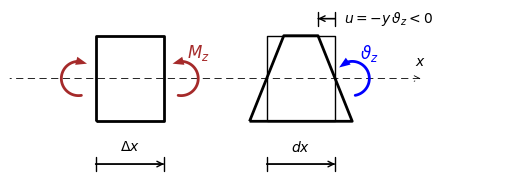

In [ ]:
fig, ax = plt.subplots(figsize=(7.12, 2))


def add_concentrated_bending_moment(
    ax,
    x, y,
    radius=0.45,
    theta1=-90,
    theta2=90,
    direction="cw",
    color="brown",
    linewidth=2.5,
    head_length=10,
    head_width=8,
    n=80,
    head_arc_deg=10.0,      # <- reserve this many degrees for the arrowhead
):
    t1 = np.deg2rad(theta1)
    t2 = np.deg2rad(theta2)

    # Reserve a small angle for the arrowhead so the tip reaches the arc end visually
    dth = np.deg2rad(head_arc_deg)

    if direction.lower() == "cw":
        # head at theta2, so stop arc early at (theta2 - dth)
        ts_arc = np.linspace(t1, t2 - dth, n)
        th_end = t2
        th_prev = t2 - dth
    elif direction.lower() == "ccw":
        # head at theta1, so start arc late at (theta1 + dth)
        ts_arc = np.linspace(t1 + dth, t2, n)
        th_end = t1
        th_prev = t1 + dth
    else:
        raise ValueError("direction must be 'cw' or 'ccw'")

    # Arc polyline (no head)
    xs = x + radius * np.cos(ts_arc)
    ys = y + radius * np.sin(ts_arc)
    ax.plot(xs, ys, color=color, linewidth=linewidth, solid_capstyle="round", zorder=5)

    # Arrowhead: tangent segment over the reserved angle
    end = np.array([x + radius * np.cos(th_end),  y + radius * np.sin(th_end)])
    prev = np.array([x + radius * np.cos(th_prev), y + radius * np.sin(th_prev)])

    head = FancyArrowPatch(
        prev, end,
        arrowstyle=f"-|>,head_length={head_length},head_width={head_width}",
        linewidth=0,
        facecolor=color,
        edgecolor=color,
        shrinkA=0, shrinkB=0,
        zorder=6,
    )
    ax.add_patch(head)

    return head

section_height = 1.0
length=0.8

# Draw the beam segment as a thick line
ax.plot(
    [
        0, 
        length, 
        length, 
        0, 
        0
    ], 
    [
        -section_height/2, 
        -section_height/2, 
        section_height/2, 
        section_height/2, 
        -section_height/2
    ], 
    color='black', 
    linewidth=2, 
    solid_capstyle='butt'
)

# Mz
mz_arrow_offset_x = 0.2
mz_text_offset_x = 0.4
mz_text_offset_y = 0.3
# on the right side of the beam segment
add_concentrated_bending_moment(
    ax,
    x=length + mz_arrow_offset_x, 
    y=0,           # slightly above beam
    radius=0.2,
    theta1=-100, theta2=120,  # near-semicircle
    direction="cw",         # makes the head appear on the left like your screenshot
    color="brown",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
)
ax.text(
    length + mz_text_offset_x,
    mz_text_offset_y,
    r"$M_z$",
    ha="center",
    va="center",
    color="brown",
    fontsize=12
)
# on the left side of the beam segment
add_concentrated_bending_moment(
    ax,
    x= -mz_arrow_offset_x, 
    y=0,           # slightly above beam
    radius=0.2,
    theta1=60, theta2=280,  # near-semicircle
    direction="ccw",         # makes the head appear on the left like your screenshot
    color="brown",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
)

# Draw the beam as a thick line
second_figure_offset = 2.0
ax.plot(
    [
        second_figure_offset, 
        second_figure_offset + length, 
        second_figure_offset + length, 
        second_figure_offset, 
        second_figure_offset
    ],
    [
        -section_height/2,
        -section_height/2, 
        section_height/2, 
        section_height/2, 
        -section_height/2
    ], 
    color='black', 
    linewidth=1, 
    solid_capstyle='butt'
)
deformation_offset_x = 0.2
ax.plot(
    # x coordinates
    [
        second_figure_offset - deformation_offset_x, 
        second_figure_offset + length + deformation_offset_x, 
        second_figure_offset + length - deformation_offset_x, 
        second_figure_offset + deformation_offset_x, 
        second_figure_offset - deformation_offset_x
    ],
    # y coordinates 
    [
        -section_height/2, 
        -section_height/2, 
        section_height/2, 
        section_height/2, 
        -section_height/2
    ], 
    color='black', 
    linewidth=2, 
    solid_capstyle='butt',
)

# arrow for rotation
add_concentrated_bending_moment(
    ax,
    x=second_figure_offset + length + mz_arrow_offset_x, 
    y=0,           # slightly above beam
    radius=0.2,
    theta1=-80, theta2=140,  # near-semicircle
    direction="cw",         # makes the head appear on the left like your screenshot
    color="b",
    linewidth=2.0,
    head_length=8,
    head_width=3,
    head_arc_deg=30,
)
ax.text(
    second_figure_offset + length + mz_text_offset_x,
    mz_text_offset_y,
    r"$\vartheta_z$",
    ha="center",
    va="center",
    color="b",
    fontsize=12
)

# horizontal dimension lines
dimension_line_y = -section_height/2 - 0.5
dimension_segments = [
    (0, length, "$dx$"),
    (second_figure_offset, second_figure_offset+length, "$dx$")
]
arrows = '<-', '|-|'
for segment in dimension_segments:
    for arr in arrows:
        arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
        if arr == '|-|':
            arrowprops["mutation_scale"] = 5
        ax.annotate(
            "", 
            xy=(segment[0], dimension_line_y), 
            xytext=(segment[1], dimension_line_y), 
            arrowprops=arrowprops
        )
    bbox=dict(fc="white", ec="none")
    ax.text((segment[0] + segment[1]) / 2, dimension_line_y + 0.2, segment[2], color="black", \
        ha="center", va="center", bbox=bbox, fontsize=10)
    
# du
du_offset_y = 0.2
du_y = section_height/2 + du_offset_y
arrows = '<-', '|-|'
for arr in arrows:
    arrowprops=dict(arrowstyle=arr, shrinkA=0, shrinkB=0)
    if arr == '|-|':
        arrowprops["mutation_scale"] = 5
    ax.annotate(
        "", 
        xy=(second_figure_offset + length, du_y), 
        xytext=(second_figure_offset + length - deformation_offset_x, du_y), 
        arrowprops=arrowprops
    )
ax.text(
    second_figure_offset + length + 0.1,
    du_y,
    r"$u = -y \, \vartheta_z < 0$",
    ha="left",
    va="center",
    color="black",
    fontsize=10
)

ax.annotate(
    "", 
    xy=(-1, 0), 
    xytext=(second_figure_offset + length + 1.0, 0), 
    arrowprops=dict(
        arrowstyle='<-',
        shrinkA=0,
        shrinkB=0,
        linewidth=0.6,
        linestyle=(0, (8, 6))  # coarse dashed: 4pt dash, 6pt gap
    ),
    color='black',
)
ax.text(
    second_figure_offset + length + 1.0,
    0.2,
    r"$x$",
    ha="center",
    va="center",
    color="black",
    fontsize=10
)

# I want to keep the aspect ratio fixed
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1, length + 4)
ax.set_ylim(-1, 0.8)
ax.axis('off')
plt.show()

#save_png_images(fig, "sign_convention_beam_Vy")